In [6]:
import sys
from pathlib import Path
sys.path.append("/export/home/mickler/boa")

import hydra
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

from boa.model.module import ChgLightningModule

run_path = Path("/export/scratch/mklockow/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

# cfg = OmegaConf.load(config_path)

with initialize(config_path="../configs"):
    cfg = compose(config_name="test.yaml", overrides=["eval=benzene"])

datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
model = ChgLightningModule.load_from_checkpoint(model_path, map_location="cpu")

/tmp/ipykernel_3024451/1987802799.py:20: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="../configs"):
/export/home/mickler/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)


Unique atom types: [1 6 7 8 9]
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.


/export/home/mickler/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+2x2e+1x3o -> 7x0e+4x1o+2x2e+1x3o | 70 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (7): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+8x1o+4x2e+2x3o+1x4e -> 16x0e+8x1o+4x2e+2x3o+1x4e | 341 weights)
            )
            (8): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
            (9): StableLinearNodeOperatorAtom(
              (linear1): Linear(16x0e+9x1o+4x2e+2x3o+1x4e -> 16x0e+9x1o+4x2e+2x3o+1x4e | 358 weights)
            )
          )

In [2]:
datamodule.setup("fit")
val_set = datamodule.val_dataset
sample = val_set[0]
print(sample)

Precomputing train density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
OFData(
  pos=[12, 3],
  atomic_numbers=[12],
  coeffs=[714],
  atom_ind=[12],
  n_basis_per_atom=[12],
  atom_ptr=[12],
  basis_function_ind=[714],
  coeff_ind_to_node_ind=[714],
  dual_basis_integrals=[714],
  irreps_per_atom=[12],
  representations={
    pos=Representation.NONE,
    atomic_numbers=Representation.NONE,
    coeffs=Representation.VECTOR,
    ground_state_coeffs=Representation.VECTOR,
    gradient_label=Representation.GRADIENT,
    energy_label=Representation.SCALAR,
    has_energy_label=Representation.NONE,
    atom_ind=Representation.NONE,
    n_basis_per_atom=Representation.NONE,
    atom_ptr=Representation.NONE,
    basis_function_ind=Representation.NONE,
    coeff_ind_to_node_ind=Representation.NONE,
    dual_basis_integrals=Representation.DUAL_VECTOR,
    mol_id=Representation.NONE,
    scf_iteration=Representation.NONE,
    irreps_per_atom=Representation.NONE,

In [3]:
import pyvista as pv

In [4]:
import pyvista as pv
from mldft.utils.visualize_3d import get_sticks_mesh_dict
from mldft.utils.molecules import build_molecule_ofdata

# Alternative approach using matplotlib backend
# pv.set_jupyter_backend('static')  # Use static backend for notebooks
# You can also try these other backends:
pv.set_jupyter_backend('html')    # Interactive with panel
# pv.set_jupyter_backend('trame')    # Interactive with trame
# pv.set_jupyter_backend('pythreejs') # Interactive with pythreejs

mol = build_molecule_ofdata(sample)

pl = pv.Plotter(notebook=True)
pl.add_mesh(**get_sticks_mesh_dict(mol))
pl.show()

2025-09-22 20:55:17.019 (  81.123s) [    713F71BEA740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [10]:
model.gto_dict

ModuleDict(
  (1): GTOs(Lmax=3, n_orbitals=14, n_contracted=14.0, outdim=36)
  (6): GTOs(Lmax=4, n_orbitals=31, n_contracted=31.0, outdim=83)
  (7): GTOs(Lmax=4, n_orbitals=31, n_contracted=31.0, outdim=83)
  (8): GTOs(Lmax=4, n_orbitals=32, n_contracted=32.0, outdim=86)
  (9): GTOs(Lmax=4, n_orbitals=32, n_contracted=32.0, outdim=86)
)

In [22]:
import numpy as np
from scipy.spatial.distance import cdist

def compute_gaussian_product_peaks(sample, gto_dict, min_distance_threshold=0.1):
    """
    Compute the peaks of Gaussian products for neighboring atoms within cutoff.
    
    When two Gaussians exp(-α₁|r-R₁|²) and exp(-α₂|r-R₂|²) are multiplied,
    the product is a Gaussian with peak at: R_peak = (α₁R₁ + α₂R₂)/(α₁ + α₂)
    
    Args:
        sample: Molecule data containing positions, atomic numbers, edge_index
        gto_dict: Dictionary of GTOs for each atom type
        min_distance_threshold: Minimum distance between peaks to avoid duplicates
    
    Returns:
        peak_coords: Tensor of shape (N_peaks, 3) with peak coordinates
        peak_info: List of dictionaries with metadata for each peak
    """
    
    # Get molecular information
    atomic_numbers = sample.atomic_numbers
    positions = sample.pos
    edge_index = sample.edge_index
    
    # Store all peaks and their metadata
    all_peaks = []
    peak_info = []
    
    # Process each edge (atom pair)
    for edge_idx in range(edge_index.shape[1]):
        atom_i_idx = edge_index[0, edge_idx].item()
        atom_j_idx = edge_index[1, edge_idx].item()
        
        # Skip self-loops for now (we could include them for completeness)
        if atom_i_idx == atom_j_idx:
            continue
            
        atom_i_type = atomic_numbers[atom_i_idx].item()
        atom_j_type = atomic_numbers[atom_j_idx].item()
        
        pos_i = positions[atom_i_idx]
        pos_j = positions[atom_j_idx]
        
        # Check if atoms are within cutoff distance
        distance = torch.norm(pos_i - pos_j).item()
        
        # Get GTOs for both atoms
        gto_i = gto_dict[str(atom_i_type)]
        gto_j = gto_dict[str(atom_j_type)]
        
        if distance > max(gto_i.cutoff, gto_j.cutoff):
            continue
            
        # Get exponents for both atoms
        expos_i = gto_i.expos
        expos_j = gto_j.expos
        
        # Compute peaks for all combinations of basis functions
        for k, exp_i in enumerate(expos_i):
            for l, exp_j in enumerate(expos_j):
                # Peak of product of two Gaussians: weighted average of centers
                alpha_i = exp_i.item()
                alpha_j = exp_j.item()
                
                # Peak position: (α₁R₁ + α₂R₂)/(α₁ + α₂)
                peak_pos = (alpha_i * pos_i + alpha_j * pos_j) / (alpha_i + alpha_j)
                
                # Store peak information
                peak_info_dict = {
                    'atom_i_idx': atom_i_idx,
                    'atom_j_idx': atom_j_idx,
                    'atom_i_type': atom_i_type,
                    'atom_j_type': atom_j_type,
                    'atom_i_pos': pos_i.clone(),
                    'atom_j_pos': pos_j.clone(),
                    'basis_i_idx': k,
                    'basis_j_idx': l,
                    'exp_i': alpha_i,
                    'exp_j': alpha_j,
                    'distance': distance,
                    'peak_pos': peak_pos.clone()
                }
                
                all_peaks.append(peak_pos)
                peak_info.append(peak_info_dict)
    
    if not all_peaks:
        return torch.empty(0, 3), []
    
    # Convert to tensor
    peak_coords = torch.stack(all_peaks)
    
    # Remove duplicates that are too close together
    if min_distance_threshold > 0:
        unique_peaks = []
        unique_info = []
        
        for i, (peak, info) in enumerate(zip(peak_coords, peak_info)):
            is_duplicate = False
            for existing_peak in unique_peaks:
                if torch.norm(peak - existing_peak) < min_distance_threshold:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                unique_peaks.append(peak)
                unique_info.append(info)
        
        if unique_peaks:
            peak_coords = torch.stack(unique_peaks)
            peak_info = unique_info
        else:
            peak_coords = torch.empty(0, 3)
            peak_info = []
    
    return peak_coords, peak_info

# Test the function
peaks, peak_info = compute_gaussian_product_peaks(sample, model.gto_dict, min_distance_threshold=0)
print(f"Found {len(peaks)} unique Gaussian product peaks")
print(f"Peak coordinates shape: {peaks.shape}")

Found 46806 unique Gaussian product peaks
Peak coordinates shape: torch.Size([46806, 3])


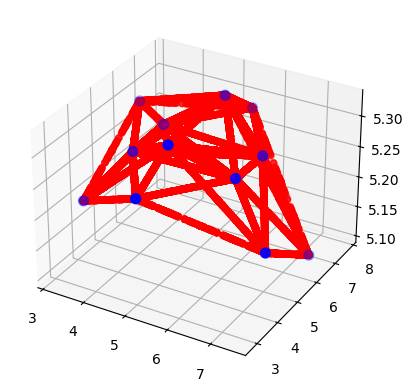

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(peaks[:, 0], peaks[:, 1], peaks[:, 2], color='red', s=20)
ax.scatter(sample.pos[:, 0], sample.pos[:, 1], sample.pos[:, 2], color='blue', s=50)

In [33]:
# Create corrected visualization with matching coordinate systems
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(**get_sticks_mesh_dict(mol))
# Use peaks_bohr instead of peaks to match the coordinate system
plotter.add_points(peaks_bohr.numpy(), color='red', point_size=10, render_points_as_spheres=True)
plotter.show()

2025-09-22 21:35:10.422 (2474.525s) [    713F71BEA740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x653466491820): Unable to eglMakeCurrent: 12291
2025-09-22 21:35:10.890 (2474.994s) [    713F71BEA740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x653461eed840): Unable to eglMakeCurrent: 12291


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Gaussian Product Peak Analysis

This notebook implements a function to compute and visualize the peaks of Gaussian product functions for neighboring atoms in a molecule. 

### Theory

When two Gaussian functions are multiplied:
- $G_1(r) = \exp(-\alpha_1 |r - R_1|^2)$ centered at $R_1$ with exponent $\alpha_1$
- $G_2(r) = \exp(-\alpha_2 |r - R_2|^2)$ centered at $R_2$ with exponent $\alpha_2$

Their product is also a Gaussian with peak located at:
$$R_{peak} = \frac{\alpha_1 R_1 + \alpha_2 R_2}{\alpha_1 + \alpha_2}$$

This represents the weighted average of the two centers, where the weights are the Gaussian exponents.

### Implementation

The main functions provided are:

1. **`compute_gaussian_product_peaks_advanced()`**: Computes all significant Gaussian product peaks between neighboring atoms within a cutoff distance.

2. **`visualize_enhanced_gaussian_peaks()`**: Creates a PyVista visualization showing both the molecular structure and the computed peaks.

3. **`analyze_gaussian_interactions()`**: Complete analysis function that combines computation and visualization.

### Key Features

- **Filtering**: Removes duplicate peaks and filters by distance, exponent ranges, and interaction strength
- **Ranking**: Sorts peaks by interaction strength (1/(α₁ + α₂))
- **Visualization**: Shows peaks as colored spheres scaled by interaction strength
- **Analysis**: Provides statistics on interaction types and strengths

### Usage

```python
# Analyze Gaussian interactions for a molecule
peaks, info = analyze_gaussian_interactions(sample, model.gto_dict)
```

The visualization shows:
- **Original molecule**: Atoms and bonds as sticks/spheres
- **Gaussian peaks**: Colored spheres representing interaction strength
- **Labels**: Annotations for the strongest interactions

This analysis helps understand where significant orbital overlap occurs in the molecule, which is crucial for electron density prediction models.